In [29]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.filters import sobel
from skimage.restoration import denoise_tv_chambolle
import os

In [31]:
def AHE(img):
    
    # Split the color image into its three color channels
    blue, green, red = cv2.split(img)

    blue = cv2.GaussianBlur(blue, (11, 11), 0)
    green = cv2.GaussianBlur(green, (11, 11), 0)
    red = cv2.GaussianBlur(red, (11, 11), 0)

    # Apply Adaptive Histogram Equalization (AHE) to each channel
    blue = cv2.createCLAHE(clipLimit=3, tileGridSize=(8, 8)).apply(blue)
    green = cv2.createCLAHE(clipLimit=3, tileGridSize=(8, 8)).apply(green)
    red = cv2.createCLAHE(clipLimit=3, tileGridSize=(8, 8)).apply(red)

    # Display image
    result_image = cv2.merge([blue, green, red])

    return result_image



In [32]:
def LoG(img):

    # Split the color image into its three color channels
    blue, green, red = cv2.split(img)

    # Apply Gaussian blur filter to each channel
    green = cv2.GaussianBlur(green, (5, 5), 0)
    blue = cv2.GaussianBlur(green, (5, 5), 0)
    red = cv2.GaussianBlur(green, (5, 5), 0)

    # Now you can apply Laplacian of Gaussian (LoG) edge detection to each channel
    blue = cv2.Laplacian(blue, cv2.CV_8U)
    green = cv2.Laplacian(green, cv2.CV_8U)
    red = cv2.Laplacian(red, cv2.CV_8U)

    result_image = cv2.merge([blue, green, red])
    # result_image = np.uint8(result_image)
    # rst_img = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)
    # plt.imshow(rst_img)

    return result_image

In [33]:
def MF(img):

    # Split the color image into its three color channels
    blue, green, red = cv2.split(img)

    # Apply median filter to each channel
    green = cv2.medianBlur(green, 5)
    green = cv2.GaussianBlur(green, (9, 9), 0)

    blue = cv2.medianBlur(blue, 5)
    blue = cv2.GaussianBlur(blue, (9, 9), 0)

    red = cv2.medianBlur(red, 5)
    red = cv2.GaussianBlur(red, (9, 9), 0)

    result_image = cv2.merge([blue, green, red])
    # result_image = np.uint8(result_image)
    # rst_img = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)
    # plt.imshow(rst_img)

    return result_image

In [34]:
def enhance(img,img_name):

    # Apply Adaptive Histogram Equalization (AHE)
    AHE_image = AHE(img)

    # Apply Laplacian of Gaussian (LoG) edge detection
    LoG_image = LoG(AHE_image)

    # Apply median filter
    MF_image = MF(LoG_image)

    # Convert the equalized channels to grayscale
    equalized_img = np.uint8(MF_image)
    equalized_img = np.uint8(equalized_img)  # Convert to uint8

    rst_img = cv2.cvtColor(equalized_img, cv2.COLOR_BGR2GRAY)

    # Create a mask of the edges image using np.dstack()
    mask = np.dstack([rst_img]*3)

    # Now overlay the two images using np.where()
    overlay = np.where(mask, 20, img)

    # Make the overlay semi-transparent by combining it with the original image using cv2.addWeighted()
    alpha = 0.5  # Define the transparency factor
    final_image = cv2.addWeighted(img, alpha, overlay, 1 - alpha, 0)

    # Display the original and enhanced images side by side
    fig, axes = plt.subplots(1, 5, figsize=(12, 6))
    plt.rc('font', size=7) 
    axes[0].set_title('Original Image')
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')

    axes[1].set_title('Adaptive Histogram Equalization')
    axes[1].imshow(cv2.cvtColor(AHE_image, cv2.COLOR_BGR2RGB))
    axes[1].axis('off')

    axes[2].set_title('Laplacian of Gaussian Edge Detection')
    LoG_image = np.uint8(LoG_image)
    axes[2].imshow(cv2.cvtColor(LoG_image, cv2.COLOR_BGR2GRAY))
    axes[2].axis('off')

    axes[3].set_title('Median Filter')
    MF_image = np.uint8(MF_image)
    axes[3].imshow(cv2.cvtColor(MF_image, cv2.COLOR_BGR2GRAY))
    axes[3].axis('off')

    axes[4].set_title('Final Image')
    axes[4].imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    axes[4].axis('off')

    if not os.path.exists('Plots'):
        os.mkdir('Plots')

    plt.tight_layout()
    plt.savefig('Plots/' + img_name + '.jpeg', bbox_inches='tight')
    # plt.show()


    if not os.path.exists('Results'):
        os.mkdir('Results')

    cv2.imwrite('Results/' + img_name + '.jpeg', final_image)

Image loaded successfully
Number of color channels: 3


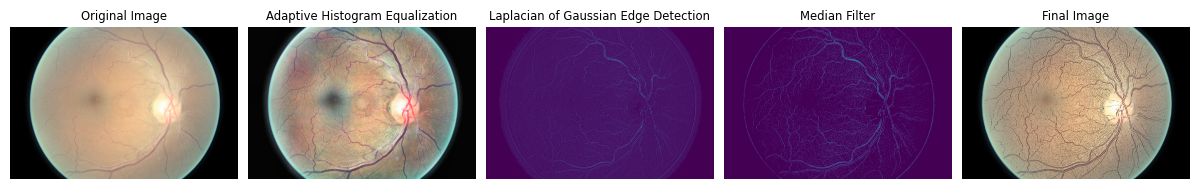

In [27]:
# Enhance specific image
img_name = '108_left'
img_path = 'Inputs/' + img_name + '.jpeg'
img = cv2.imread(img_path, cv2.IMREAD_COLOR)

# Check if the image is loaded correctly
if img is None:
    print("Image not loaded")
else:
    print("Image loaded successfully")

# Check the number of color channels in the image
print("Number of color channels:", img.shape[2])

enhance(img,img_name)

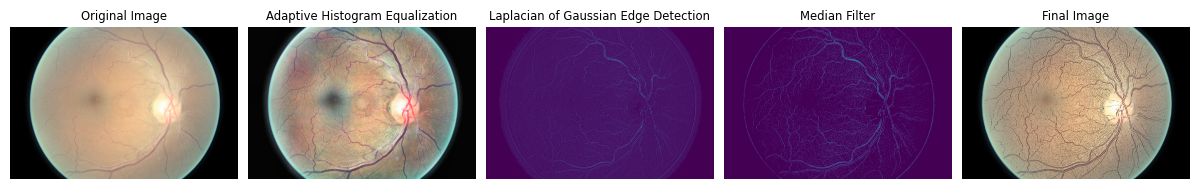

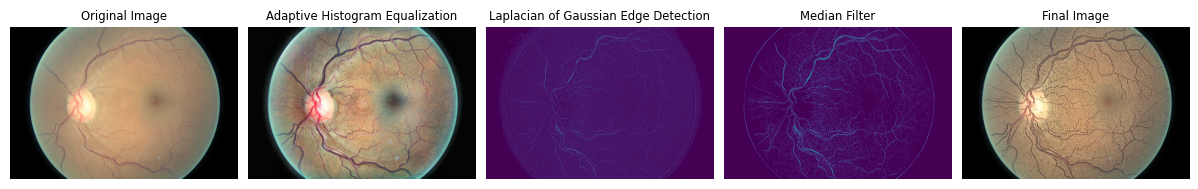

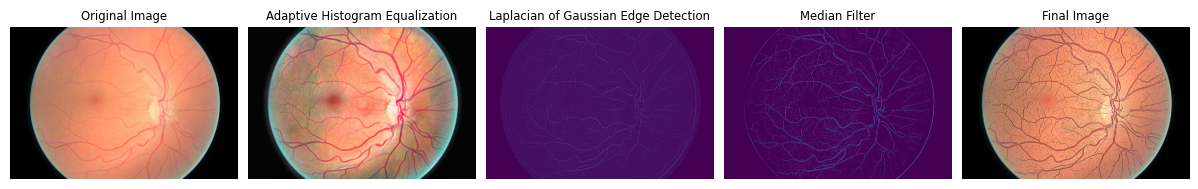

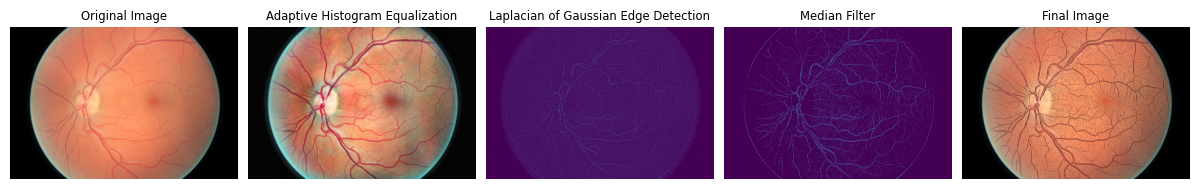

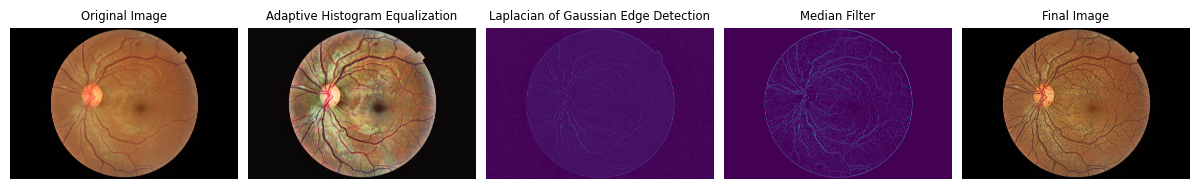

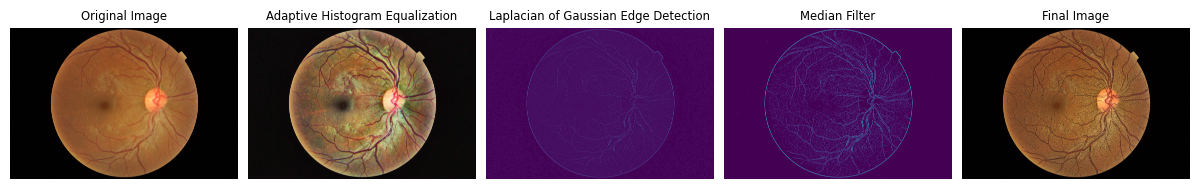

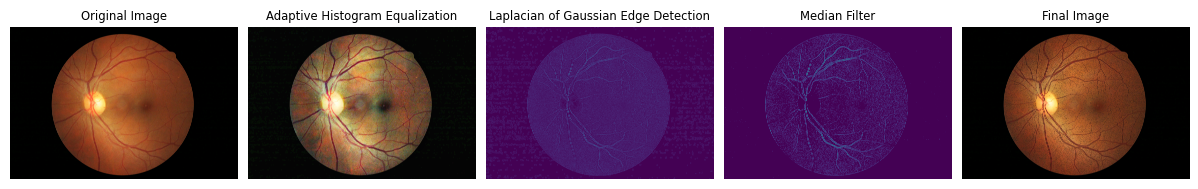

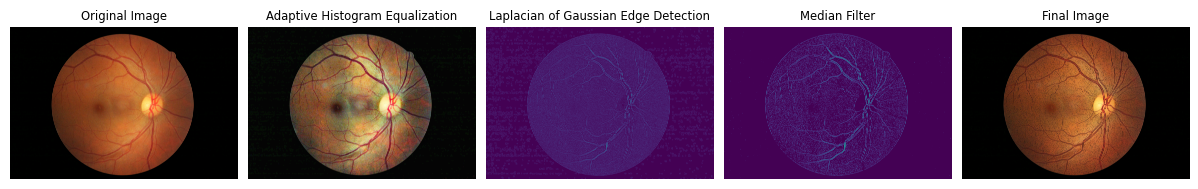

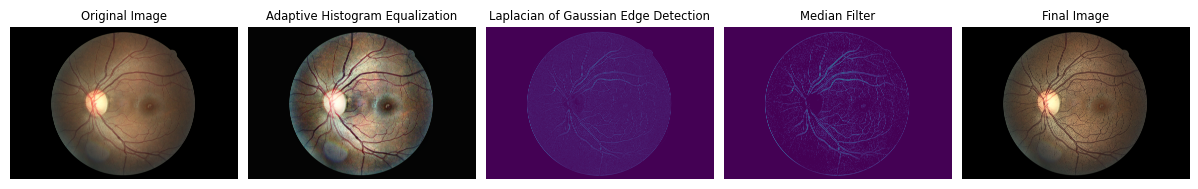

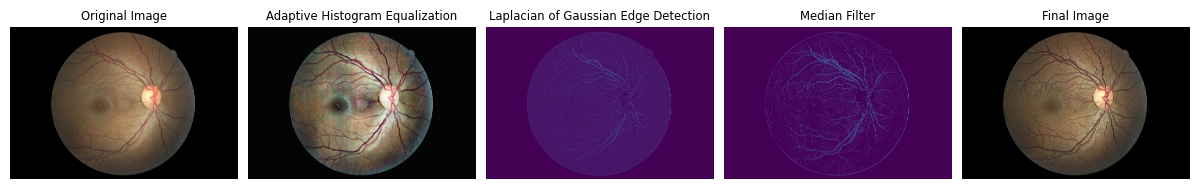

In [35]:
# Enhance All Inputs
InputFolder = ".\\Inputs"
filesArray = [x for x in os.listdir(InputFolder) if os.path.isfile(os.path.join(InputFolder,x))]

for file_name in filesArray:
    original_image = cv2.imread(InputFolder+"\\"+file_name)
    file_name_no_extension = os.path.splitext(file_name)[0]
    enhance(original_image,file_name_no_extension)